# Using several classifiers and tuning parameters - Parameters grid
[From official `scikit-learn` documentation](http://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_digits.html)

Adapted by Claudio Sartori

Example of usage of the ***model selection*** features of `scikit-learn` and comparison of several classification methods.
1. import a sample dataset 
1. do the usual preliminary data explorations and separate the predicting attributes from the *target* `'Exited'`
1. define the _models_ that will be tested and prepare the _hyperparameter ranges_ for the modules
1. set the list of *score functions* to choose from
1. split the dataset into two parts: train and test
1. Loop on score functions and, for each score, loop on the model labels (see details below)
    - optimize with GridSearchCV
    - test
    - store the results of best model
1. for each scoring show the best models for each classifier, sorted by decreasing performance
1. for each scoring show the confusion matrix of the prediction given by the best model

In [5]:
"""
@author: scikit-learn.org and Claudio Sartori
"""
import warnings
warnings.filterwarnings('ignore') # uncomment this line to suppress warnings

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

print(__doc__) # print information included in the triple quotes at the beginning


@author: scikit-learn.org and Claudio Sartori



# 0. Initial settings
Set the random state and set the seed with `np.random.seed()`

Set the test set size and the number of cross valitadion splits

In [6]:
ts = 0.3 # test size
random_state = 42
np.random.seed(random_state) # this sets the random sequence. Setting only this the repeatability is guaranteed
                             # only if we re-execute the entire notebook
cv = 3   # number of cross-validation splits

# 1. Import the dataset

`churn-analysis.csv` from the `data` folder

In [7]:
data = pd.read_csv(r'C:\Users\jacop\OneDrive\Documenti\BBS_Machine_Learning_public\data\churn-analysis.csv', encoding='Latin-1')

# 2. Explore the data

The output of exploration is not shown here

Dataset Preview:
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          502       0   42       8  159660.80              3          1   
2          699       0   39       1       0.00              2          0   
3          822       1   50       7       0.00              2          1   
4          501       1   44       4  142051.07              2          0   

   IsActiveMember  EstimatedSalary  Exited  
0               1        101348.88    True  
1               0        113931.57    True  
2               0         93826.63   False  
3               1         10062.80   False  
4               1         74940.50   False  

Dataset Shape: (5014, 10)

Missing Values in Each Column:
CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited  

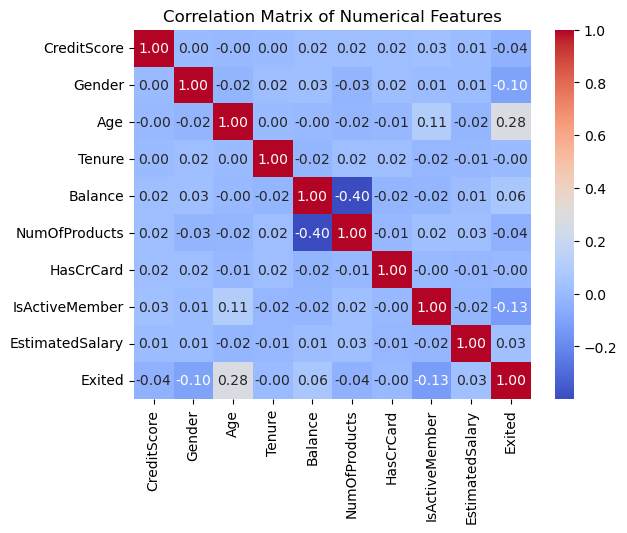

In [8]:
# Display the first few rows of the dataset
print("Dataset Preview:")
print(data.head())
# Check the dataset shape
print(f"\nDataset Shape: {data.shape}")


# Check for missing values
print("\nMissing Values in Each Column:")
print(data.isnull().sum())


# Check unique values in the target column 'Exited'
if 'Exited' in data.columns:
   print("\nUnique Values in Target Column 'Exited':")
   print(data['Exited'].value_counts())


# Check data types
print("\nData Types of Each Column:")
print(data.dtypes)


# Basic statistics for numerical columns
print("\nSummary Statistics for Numerical Columns:")
print(data.describe())


# Check for categorical columns and their unique values
categorical_columns = data.select_dtypes(include=['object', 'category']).columns
print("\nCategorical Columns and Unique Values:")
for col in categorical_columns:
   print(f"{col}: {data[col].nunique()} unique values")
   print(data[col].value_counts().head())  # Show top unique values


# Correlation matrix
print("\nCorrelation Matrix:")
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

TypeError: 'tuple' object is not callable

# 3. Define the _models_ 
Prepare the _hyperparameter ranges_ for the modules

Put everything in a dictionary, for ease of use

Please read carefully these data structures and understand them

It is also useful to read the API documentation of each classifier, in order to understand the hyperparameters

In [9]:
model_lbls = ['dt' # decision tree
             ,'nb' # gaussian naive bayes
             ,'lp'   # linear perceptron
              ,'svc'  # support vector # deactivate if running time becomes too long
             ,'knn'  # k nearest neighbours
             ,'adb'  # adaboost
             ,'rf'   # random forest
            ]

models = {
    'dt': {'name': 'Decision Tree       ',
           'estimator': DecisionTreeClassifier(random_state=random_state), 
           'param': [{'max_depth': [*range(1,20)],'class_weight':[None,'balanced']}],
          },
    'nb': {'name': 'Gaussian Naive Bayes',
           'estimator': GaussianNB(),
           'param': [{'var_smoothing': [10**exp for exp in range(-3,-13,-1)]}]
          },
    'lp': {'name': 'Linear Perceptron   ',
           'estimator': Perceptron(random_state=random_state),
           'param': [{'early_stopping': [True,False],'class_weight':[None,'balanced']}],
          },
    'svc':{'name': 'Support Vector      ',
           'estimator': SVC(random_state=random_state), 
           'param': [{'kernel': ['rbf'], 
                    'gamma': [1e-3, 1e-4],
                    'C': [1, 10, 100],
                    },
                    {'kernel': ['linear'],
                     'C': [1, 10, 100],                     
             },
                   ]
          },
    'knn':{'name': 'K Nearest Neighbor ',
           'estimator': KNeighborsClassifier(),
           'param': [{'n_neighbors': list(range(1,7))}]
       },
    'adb':{'name': 'AdaBoost           ',
           'estimator': AdaBoostClassifier(random_state=random_state),
           'param': [{'n_estimators':[10,20,30,40,50]
                     ,'learning_rate':[0.2,0.5,0.75,1,1.25,1.5]}]
          },
    'rf': {'name': 'Random forest       ',
           'estimator': RandomForestClassifier(random_state=random_state),
           'param': [{'max_depth': [*range(4,10)]
                     ,'n_estimators':[*range(10,60,10)]}]
          }

}

# 4. Set the list of *score functions* to choose from

In [13]:
# 4. Set the list of score functions
scoring = {
   'accuracy': 'accuracy',  # Default scoring in many classifiers
   'f1': 'f1',  # Harmonic mean of precision and recall, good for imbalanced datasets
   'precision': 'precision',  # Precision: TP / (TP + FP)
   'recall': 'recall',  # Recall: TP / (TP + FN)
   'roc_auc': 'roc_auc',  # Receiver Operating Characteristic Area Under the Curve
}


# 5. Split the dataset into the train and test parts
    - the *train* part will be used for training and cross-validation (i.e. for *development*)
    - the *test* part will be used for test (i.e. for *evaluation*)
    - the fraction of test data will be _ts_ (a value of your choice between 0.2 and 0.5)

In [14]:
# Define the test size (e.g., ts = 0.3 as set earlier)
ts = 0.3  # Fraction of test data
random_state = 42  # Ensures reproducibility


# Separate features (X) and target (y)
target_column = 'Exited'  # Replace with the actual target column name in your dataset
X = data.drop(columns=[target_column])
y = data[target_column]


# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=random_state, stratify=y)


# Print the shape of the datasets
print(f"Training Set Shape: X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Test Set Shape: X_test: {X_test.shape}, y_test: {y_test.shape}")


# Verify class distribution in train and test sets (optional, useful for imbalanced datasets)
print("\nClass Distribution in Training Set:")
print(y_train.value_counts(normalize=True))
print("\nClass Distribution in Test Set:")
print(y_test.value_counts(normalize=True))


Training Set Shape: X_train: (3509, 9), y_train: (3509,)
Test Set Shape: X_test: (1505, 9), y_test: (1505,)

Class Distribution in Training Set:
Exited
False    0.838416
True     0.161584
Name: proportion, dtype: float64

Class Distribution in Test Set:
Exited
False    0.838538
True     0.161462
Name: proportion, dtype: float64


# 6. Loop on scores and, for each score, loop on the model labels

The function `GridSearchCV` iterates a cross validation experiment to train and test a model with different combinations of paramater values
- for each parameter we have set before a list of values to test, `ParametersGrid` will be implicitly called to generate all the combinations
- we choose a *score function* which will be used for the optimization
    - e.g. `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, see this [page](https://scikit-learn.org/stable/modules/model_evaluation.html) for reference
- the output is a dataframe containing 
    - the set of parameters maximising the score 
    - the score used for optimisation and all the test scores

### Steps

- prepare an empty list `clfs` to store all the fitte models
- prepare an empty DataFrame which will collect the results of the fittings with each combination of parameters
    - dataframe columns are `'scoring','model','best_params','accuracy','precision_macro','recall_macro','f1_macro'`
- loop

In [16]:
clfs = []
y_preds = []
results = pd.DataFrame(columns=['scoring','model','best_params'#,'fit+score_time'
                                ,'accuracy','precision_macro','recall_macro','f1_macro'])

### Parameters to collect

`classification_report` produces a dictionary containing some classification performance measures, given the *ground truth* and the *predictions* (use the parameter `output_dict=True`)

The measures are (among others):
- `accuracy`
- `macro avg` a dictionary containing:
    - `precision`
    - `recall`
    - `f1-score`
- ...


### Loop

- repeat for all the chosen scorings
    - repeat for all the chosen classification models
        - store in `clf` the initialisation of `GridSearchCV` with the appropriate
            - classification model
            - parameters ranges
            - scoring
            - cross validation method `cv` (the same for all)
        - fit `clf` with the *train* part of `X` and `y`
        - store in `y_pred` the prediction for the *test* part of `X`
        - append `clf` to clfs`
        - append `y_pred` to `y_preds`
        - store in variable `cr` the `classification_report` produced with the test part of `y` and `y_pred`
        - store in the last row of `results` a list containing:
            - the name of the model
            - the `.best_params_` of `clf`
            - a selection of the contents of cr
                - 'accuracy', 
                - 'macro avg''precision'
                - 'macro avg''recall'
                - 'macro avg''f1-score'

Hints: 
- cr is a multi-level dictionary, second level can be reached 
with <br> `cr['first level label']['second level label']`
- to append a list as the last row of a dataframe you can use <br>
`df.loc[len(df)]=[]`

In [28]:
# Iterate over each scoring metric
for score in scoring.keys():
   print(f"\nProcessing scoring: {score}")
for label in model_lbls:
       model_info = models[label]
       model_name = model_info['name']
       print(f"Optimizing model: {model_name}")
# Initialize GridSearchCV
       clf = GridSearchCV(estimator=model_info['estimator'],
                          param_grid=model_info['param'],
                          scoring=score,
                          cv=cv,
                          n_jobs=-1)  # Use all available processors
 # Fit the classifier on training data
clf.fit(X_train, y_train)
 # Store the classifier in the list
clfs.append(clf)
 # Predict on the test set
y_pred = clf.predict(X_test)
y_preds.append(y_pred)
  # Generate classification report
cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
 # Append results to the DataFrame
results.loc[len(results)] = [
           score,
           model_name,
           clf.best_params_,
           cr['accuracy'],
           cr['macro avg']['precision'],
           cr['macro avg']['recall'],
           cr['macro avg']['f1-score']
       ]
# Display the results DataFrame
print("\nResults of Model Evaluation:")
print(results)


# Optionally, save the results to a CSV file for further analysis
results.to_csv("model_evaluation_results.csv", index=False)
print("\nResults have been saved to 'model_evaluation_results.csv'")




Processing scoring: accuracy

Processing scoring: f1

Processing scoring: precision

Processing scoring: recall

Processing scoring: roc_auc
Optimizing model: Decision Tree       
Optimizing model: Gaussian Naive Bayes
Optimizing model: Linear Perceptron   
Optimizing model: Support Vector      
Optimizing model: K Nearest Neighbor 
Optimizing model: AdaBoost           
Optimizing model: Random forest       

Results of Model Evaluation:
   scoring                 model                           best_params  \
0  roc_auc  Random forest         {'max_depth': 6, 'n_estimators': 30}   
1  roc_auc  Random forest         {'max_depth': 6, 'n_estimators': 30}   

   accuracy  precision_macro  recall_macro  f1_macro  
0  0.879734         0.853261      0.655816  0.699156  
1  0.879734         0.853261      0.655816  0.699156  

Results have been saved to 'model_evaluation_results.csv'


# 7. Display

For each scoring show the ranking of the models, and the confusion matrix given by the best model

For each scoring:
- set a `scoring_filter`
- filter the results of that scoring
- display the filtered dataframe with the `display()` function (it allows several displays of dataframes )



In [38]:
# Step 7: Display rankings and confusion matrices for each scoring
for score in scoring.keys():
   print(f"\n### Results for Scoring: {score} ###")
 # Filter results for the current scoring
   scoring_filter = results['scoring'] == score
   filtered_results = results[scoring_filter]
    # Sort by accuracy (or another relevant metric if needed)
   filtered_results = filtered_results.sort_values(by='accuracy', ascending=False)
   # Display the filtered DataFrame
   print(f"Ranking for scoring: {score}")
   print(filtered_results[['model', 'accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'best_params']])
   # Get the best model for the current scoring
best_row = filtered_results.iloc[0]  # First row is the best model after sorting
best_model_name = best_row['model']
best_params = best_row['best_params']
# Retrieve and configure the best model
for label in model_lbls:
       if models[label]['name'].strip() == best_model_name.strip():
           best_model = models[label]['estimator'].set_params(**best_params)




### Results for Scoring: accuracy ###
Ranking for scoring: accuracy
Empty DataFrame
Columns: [model, accuracy, precision_macro, recall_macro, f1_macro, best_params]
Index: []

### Results for Scoring: f1 ###
Ranking for scoring: f1
Empty DataFrame
Columns: [model, accuracy, precision_macro, recall_macro, f1_macro, best_params]
Index: []

### Results for Scoring: precision ###
Ranking for scoring: precision
Empty DataFrame
Columns: [model, accuracy, precision_macro, recall_macro, f1_macro, best_params]
Index: []

### Results for Scoring: recall ###
Ranking for scoring: recall
Empty DataFrame
Columns: [model, accuracy, precision_macro, recall_macro, f1_macro, best_params]
Index: []

### Results for Scoring: roc_auc ###
Ranking for scoring: roc_auc
                  model  accuracy  precision_macro  recall_macro  f1_macro  \
0  Random forest         0.879734         0.853261      0.655816  0.699156   
1  Random forest         0.879734         0.853261      0.655816  0.699156   

        

# 8. Confusion matrices

Use the `ConfusionMatrixDisplay` with the best model of each scoring to compare the predictions

Repeat for every scoring:
- filter the results for the current scoring
- find the row with the best value of the scoring 
- display the confusion matrix with an appropriate title


Confusion Matrix for Best Model (Random forest       ) using roc_auc:


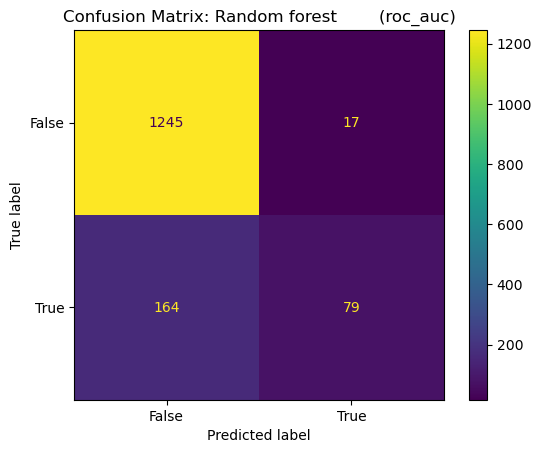

In [43]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
# Display confusion matrix
print(f"\nConfusion Matrix for Best Model ({best_model_name}) using {score}:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title(f"Confusion Matrix: {best_model_name} ({score})")
plt.show()

